# Scaling the data

---
### Author :  Muhammad Ali Saagar

**Python Developer • Data Science • AI/ML Engineer**

#### 🔗 Connect With Me

[![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AliMuhammad78)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/muhammad-ali-91294a290)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/ali98muhammad45)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@TechyBits20121)
[![Email](https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge\&logo=gmail)](mailto:alisaagar86@gmail.com)

---

### Acknowledgement

> Most of the examples in this notebook are based on the excellent tutorials by **Dr. Muhammad Aammar Tufail (Codanics)**. I sincerely thank him for sharing his knowledge and practical examples.

 [![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AammarTufail)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/dr-muhammad-aammar-tufail-02471213b/)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/muhammadaammartufail)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@codanics)

## Standardization

 ### Standard Scaling

**Standard Scaling** is a technique used to transform data so that it has a **mean of 0** and a **standard deviation of 1**. This is done by subtracting the average value of the dataset from each data point and then dividing by the dataset’s standard deviation. Standard scaling is commonly applied in machine learning because many algorithms perform better when features are on a similar scale.

The formula for standard scaling is:

\[
z = \frac{x - \mu}{\sigma}
\]

Where:  
- **x** = original value  
- **μ** = mean of the dataset  
- **σ** = standard deviation of the dataset  
- **z** = scaled value

#### Visualization

The image below shows a typical normal distribution after standard scaling:

![Standard Scaling Visualization](https://upload.wikimedia.org/wikipedia/commons/thumb/2/25/The_Normal_Distribution.svg/512px-The_Normal_Distribution.svg.png)



In [1]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler , MinMaxScaler , MaxAbsScaler

In [2]:
df = pd.DataFrame({
    "height" : [20 , 93 , 48 , 92 , 10 , 45 , 67 , 81 , 70] ,
    "weight" : [50 , 80 , 60 , 90 , 40 , 55 , 75 , 85 , 65] , 
    "age" : [20 , 30 , 25 , 35 , 22 , 28 , 32 , 40 , 27]
})
df.head()

,height,weight,age
0,20,50,20
1,93,80,30
2,48,60,25
3,92,90,35
4,10,40,22


In [3]:
scalar = MaxAbsScaler()
scalar.fit(df)
scaled_data = scalar.fit_transform(df)
scaled_data = pd.DataFrame(scaled_data, columns = df.columns)
scaled_data.head()

,height,weight,age
0,0.215054,0.555556,0.500
1,1.000000,0.888889,0.750
2,0.516129,0.666667,0.625
3,0.989247,1.000000,0.875
4,0.107527,0.444444,0.550


> let us bring back the data into original form 


In [4]:
original_data = scalar.inverse_transform(scaled_data)
original_data = pd.DataFrame(original_data, columns = df.columns)
original_data.head()

 

,height,weight,age
0,20.0,50.0,20.0
1,93.0,80.0,30.0
2,48.0,60.0,25.0
3,92.0,90.0,35.0
4,10.0,40.0,22.0


## MinMax Scalar 
- Between 0 and 1 

In [5]:
min_max_scalar = MinMaxScaler()
M_scaled = min_max_scalar.fit_transform(df) 
M_scaled = pd.DataFrame(M_scaled, columns = df.columns) 
M_scaled.head()

,height,weight,age
0,0.120482,0.2,0.00
1,1.000000,0.8,0.50
2,0.457831,0.4,0.25
3,0.987952,1.0,0.75
4,0.000000,0.0,0.10


## Using MaxAbsolute Scalar 

- from -1 to 1 

In [6]:
maxabs = MaxAbsScaler()
maxabs_data = maxabs.fit_transform(df)
maxabs_data = pd.DataFrame(maxabs_data, columns = df.columns)
maxabs_data.head()

,height,weight,age
0,0.215054,0.555556,0.500
1,1.000000,0.888889,0.750
2,0.516129,0.666667,0.625
3,0.989247,1.000000,0.875
4,0.107527,0.444444,0.550


## Robust Scalar
- No fixed range (Median=0, IQR=1)

In [7]:
from sklearn.preprocessing import RobustScaler

robust = RobustScaler()
robust_data = robust.fit_transform(df)
robust_data = pd.DataFrame(robust_data, columns = df.columns)
robust_data.head()

,height,weight,age
0,-1.305556,-0.6,-1.142857
1,0.722222,0.6,0.285714
2,-0.527778,-0.2,-0.428571
3,0.694444,1.0,1.000000
4,-1.583333,-1.0,-0.857143


## Transformation 

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097
5,2.076319
6,1.151038
7,4.447049
8,6.629824
9,0.967204


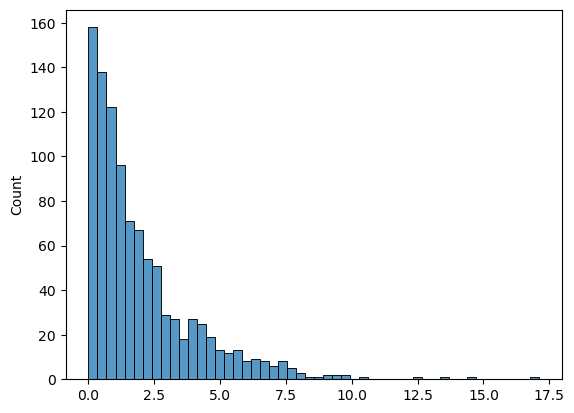

In [9]:
np.random.seed(0)
df = np.random.exponential(scale = 2, size =1000 )
sns.histplot(df, bins = 50)
df = pd.DataFrame(df, columns = ["values"])
df.head(10)

In [10]:
from sklearn.preprocessing import PowerTransformer , QuantileTransformer 
box_cox = PowerTransformer(method = "box-cox" , standardize = False)
yeo_johnson = PowerTransformer(method = "yeo-johnson" , standardize = False)
quantile = QuantileTransformer(output_distribution = "normal")

df["box_cox"] = box_cox.fit_transform(df[["values"]])
df["yeo_johnson"] = yeo_johnson.fit_transform(df[["values"]])
df["quantile"] = quantile.fit_transform(df[["values"]]) 
df.head()


,values,box_cox,yeo_johnson,quantile
0,1.591749,0.491988,0.787485,0.162552
1,2.511862,1.031744,0.980233,0.587964
2,1.846446,0.661110,0.849553,0.286135
3,1.574402,0.479742,0.782945,0.157469
4,1.102097,0.098367,0.639848,-0.154930


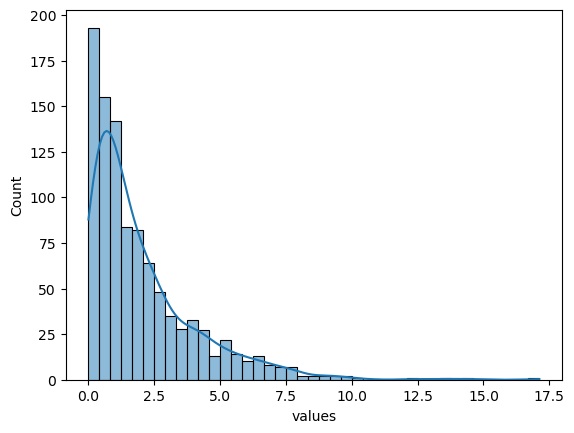

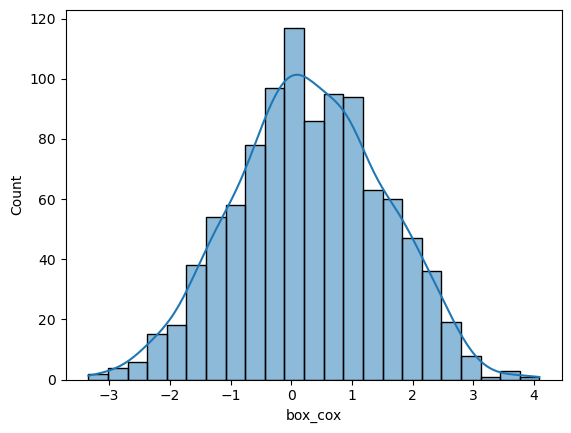

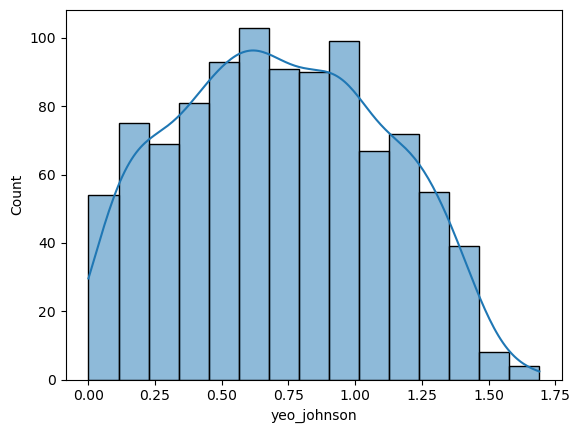

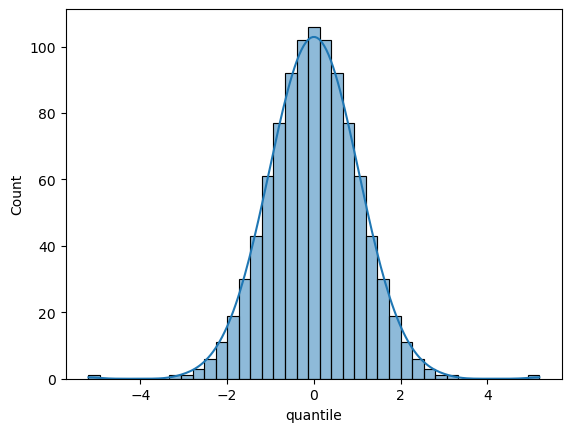

In [11]:
for col in df : 
    sns.histplot(df[col],  kde =True)
    plt.show()        

---

# Normalization of Data

### Data Normalization (Data Preprocessing)

**Normalization** is a preprocessing technique used to **rescale data so that each sample has a unit norm (length = 1)**.
In simple words, normalization adjusts the values of features so that the **relative proportions remain the same but the overall magnitude becomes 1**.

For example, if a data sample has values `[3, 4]`, its length is `5`.
After normalization → `[0.6, 0.8]`, and the new vector length becomes `1`.

Normalization is useful when we want to **compare the direction of data rather than its magnitude**, such as in **text classification, cosine similarity, and distance-based algorithms like KNN**.

---
### When to Use Normalization

Normalization is useful when:

* Using **distance-based algorithms** (KNN, K-Means)
* Working with **text data or cosine similarity**
* Features represent **direction rather than magnitude**

---
### Normalization vs Scaling

| Technique                              | Idea                             | What it does                                    |
| -------------------------------------- | -------------------------------- | ----------------------------------------------- |
| **Normalization**                      | Rescales each **data sample**    | Makes the **vector length = 1**                 |
| **Scaling (Standardization / MinMax)** | Rescales each **feature/column** | Changes the **distribution or range of values** |

Example:

Original data:

```
[10, 100]
[20, 200]
```

Scaling adjusts columns, while **normalization adjusts rows (samples)**.

---

### Types of Normalization (Norms)

In `sklearn.preprocessing.normalize`, three main norms are used:

#### 1. L1 Norm (Manhattan Norm)

The sum of absolute values becomes **1**.

Formula:

```
||x||₁ = |x1| + |x2| + ... + |xn|
```

Example:

```
[2, 3] → L1 sum = 5
Normalized → [0.4, 0.6]
```

---


In [12]:
from sklearn.preprocessing import Normalizer 

data = [ [1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]
normalizer = Normalizer(norm = "l1")
normalized_data = normalizer.fit_transform(data)
normalized_data

array([[0.16666667, 0.33333333, 0.5       ],
       [0.26666667, 0.33333333, 0.4       ],
       [0.29166667, 0.33333333, 0.375     ]])



#### 2. L2 Norm (Euclidean Norm) – Default in Scikit-Learn

The square root of the sum of squared values becomes **1**.

Formula:

```
||x||₂ = √(x1² + x2² + ... + xn²)
```

Example:

```
[3, 4] → √(9+16) = 5
Normalized → [0.6, 0.8]
```


In [13]:
from sklearn.preprocessing import Normalizer 

data = [ [1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]
normalizer = Normalizer(norm = "l2")
normalized_data = normalizer.fit_transform(data)
normalized_data

array([[0.26726124, 0.53452248, 0.80178373],
       [0.45584231, 0.56980288, 0.68376346],
       [0.50257071, 0.57436653, 0.64616234]])



---

#### 3. Max Norm

Each value is divided by the **maximum absolute value** in the vector.

Formula:

```
||x||∞ = max(|x1|, |x2|, ..., |xn|)
```

Example:

```
[2, 5, 3] → max = 5
Normalized → [0.4, 1, 0.6]
```

---

 


 


In [14]:
from sklearn.preprocessing import Normalizer 

data = [ [1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]
normalizer = Normalizer(norm = "max")
normalized_data = normalizer.fit_transform(data)
normalized_data

array([[0.33333333, 0.66666667, 1.        ],
       [0.66666667, 0.83333333, 1.        ],
       [0.77777778, 0.88888889, 1.        ]])

--- 
### Log transformation 

**Log transformation** is a data transformation technique used to **reduce skewness in data and compress large values**.
In simple words, it **shrinks large numbers more than small numbers**, making the data more balanced and easier for machine learning models to learn.

For example, if the original values are:

```
10, 100, 1000
```

After log transformation (base 10):

```
1, 2, 3
```

So very large differences in the original data become **smaller and more manageable**.

---

#### Why Log Transformation is Used

Log transformation is mainly used to:

* **Reduce right-skewed distributions** (long tail on the right side).
* **Reduce the effect of extreme values (outliers)**.
* **Make data closer to a normal distribution**.
* **Stabilize variance** in the dataset.
* Help algorithms that work better with **normally distributed data** (like Linear Regression).

---

#### When to Use Log Transformation

Use log transformation when:

1. **Data is highly skewed**

   * Example: income, house prices, population, sales.

2. **Values increase exponentially**

   * Example: viral growth, investment growth.

3. **Large range of values**

   * Example: values like 10, 1000, 100000.

4. **Variance increases with magnitude**

   * Large values vary much more than small values.

---

#### Basic Log Scales

Different logarithmic bases can be used:

**Log base 10 (log₁₀)**

* Most common for understanding large magnitude differences.
* Example: scientific measurements.

**Natural log (ln or logₑ)**

* Uses base **e ≈ 2.718**.
* Common in **statistics and machine learning**.

**Log base 2 (log₂)**

* Often used in **computer science and information theory**.

In machine learning, **natural log (ln)** is most commonly used.

---

#### Important Note

Log transformation **cannot be applied to zero or negative values** because logarithm is undefined for them.

A common solution is to **add a small constant (like +1)** before applying the log.

Example:

```
log(x + 1)
```

---

#### Effect of Log Transformation

Log transformation:

* **Compresses large values**
* **Spreads smaller values slightly**
* **Reduces skewness**
* **Makes patterns easier for models to detect**

---

#### Simple Intuition

If a dataset contains values like:

```
10, 20, 30, 1000
```

The value **1000 dominates the dataset**.
After log transformation:

```
~2.3, ~3.0, ~3.4, ~6.9
```

Now the difference between values becomes **more balanced**, which helps machine learning algorithms perform better.

---
 


In [15]:
import pandas as pd 
import numpy as np 

df = pd.DataFrame({ "Values" : [ 1, 10 , 30 , 49 , 87 , 100 , 4485 ,  10000 , 13893 , 100042  , 1000000]})
df.head()

,Values
0,1
1,10
2,30
3,49
4,87


In [16]:
df["log-values"] = np.log(df["Values"])
df.head(12)

,Values,log-values
0,1,0.000000
1,10,2.302585
2,30,3.401197
3,49,3.891820
4,87,4.465908
5,100,4.605170
6,4485,8.408494
7,10000,9.210340
8,13893,9.539140
9,100042,11.513345


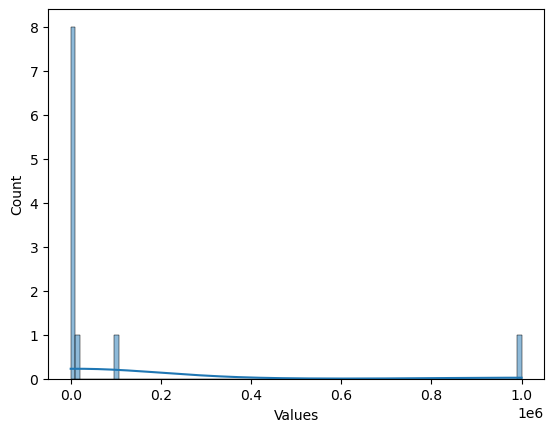

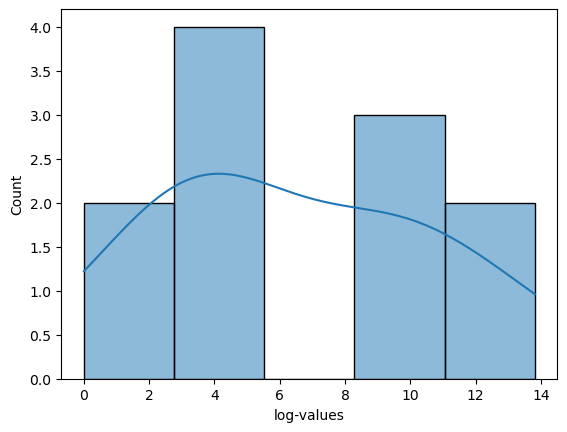

In [17]:
for col in df: 
    sns.histplot(df[col], kde = True)
    plt.show()